# 03 — Random Forest

Pipeline :
1. Chargement des features depuis `data/processed/`
2. `RandomForestClassifier` avec hyperparamètres de l'article
3. Validation croisée 10-fold stratifiée sur le dataset complet (train + test)
4. Métriques par fold et moyennes : accuracy, precision, recall, F1, AUC, MCC
5. Comparaison avec les résultats de l'article
6. Sauvegarde dans `results/results_rf.json`

In [1]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, roc_curve
)
import joblib

sns.set_theme(style='whitegrid')
%matplotlib inline

ROOT = Path('..').resolve()
PROCESSED = ROOT / 'data' / 'processed'
RESULTS   = ROOT / 'results'
MODELS    = ROOT / 'models'
RANDOM_STATE = 42

## 1. Chargement des features

In [2]:
X_train = np.load(PROCESSED / 'X_train.npy')
X_test  = np.load(PROCESSED / 'X_test.npy')
y_train = np.load(PROCESSED / 'y_train.npy')
y_test  = np.load(PROCESSED / 'y_test.npy')

# Combiner pour la CV 10-fold (comme dans l'article)
X = np.vstack([X_train, X_test])
y = np.concatenate([y_train, y_test])

print(f'X_train : {X_train.shape}  X_test : {X_test.shape}')
print(f'Dataset complet : {X.shape}')
print(f'Distribution y : cls=0 → {(y==0).sum()} ({(y==0).mean():.1%})  cls=1 → {(y==1).sum()} ({(y==1).mean():.1%})')

X_train : (39263, 480)  X_test : (4433, 480)
Dataset complet : (43696, 480)
Distribution y : cls=0 → 32461 (74.3%)  cls=1 → 11235 (25.7%)


## 2. Noms de features
480 colonnes = 160 one-hot squid + 5 lignes × 64 dims W2V

In [3]:
N_SQUID  = 160
W2V_DIM  = 64
LINES    = ['line_m2', 'line_m1', 'line_0', 'line_1', 'line_2']

feat_names = ([f'squid_{i}' for i in range(N_SQUID)] +
              [f'w2v_{l}_d{d}' for l in LINES for d in range(W2V_DIM)])

assert len(feat_names) == X.shape[1], f'Attendu {X.shape[1]} features, obtenu {len(feat_names)}'
print(f'{len(feat_names)} features nommées — OK')

480 features nommées — OK


## 3. Entraînement — Random Forest (hyperparamètres article)

In [4]:
rf = RandomForestClassifier(
    n_estimators     = 250,
    max_depth        = 100,
    min_samples_split= 10,
    min_samples_leaf = 1,
    criterion        = 'entropy',
    class_weight     = 'balanced',
    n_jobs           = -1,
    random_state     = RANDOM_STATE
)
print('RandomForestClassifier configuré :')
print(rf)

RandomForestClassifier configuré :
RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=100, min_samples_split=10, n_estimators=250,
                       n_jobs=-1, random_state=42)


## 4. Validation croisée 10-fold stratifiée

In [5]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

fold_results = []
all_y_true, all_y_pred, all_y_prob = [], [], []

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)
    y_prob = rf.predict_proba(X_te)[:, 1]

    metrics = {
        'fold'      : fold_i,
        'accuracy'  : accuracy_score(y_te, y_pred),
        'precision' : precision_score(y_te, y_pred, zero_division=0),
        'recall'    : recall_score(y_te, y_pred, zero_division=0),
        'f1'        : f1_score(y_te, y_pred, zero_division=0),
        'auc'       : roc_auc_score(y_te, y_prob),
        'mcc'       : matthews_corrcoef(y_te, y_pred),
    }
    fold_results.append(metrics)
    all_y_true.extend(y_te)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)

    print(f'Fold {fold_i:2d} | Acc {metrics["accuracy"]:.4f} | '
          f'F1 {metrics["f1"]:.4f} | AUC {metrics["auc"]:.4f}')

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

Fold  1 | Acc 0.8902 | F1 0.7940 | AUC 0.9440
Fold  2 | Acc 0.8915 | F1 0.7932 | AUC 0.9440
Fold  3 | Acc 0.9053 | F1 0.8184 | AUC 0.9500
Fold  4 | Acc 0.8982 | F1 0.8071 | AUC 0.9463
Fold  5 | Acc 0.9071 | F1 0.8192 | AUC 0.9500
Fold  6 | Acc 0.9023 | F1 0.8135 | AUC 0.9506
Fold  7 | Acc 0.8961 | F1 0.7998 | AUC 0.9453
Fold  8 | Acc 0.8952 | F1 0.8003 | AUC 0.9404
Fold  9 | Acc 0.8959 | F1 0.7995 | AUC 0.9472
Fold 10 | Acc 0.9064 | F1 0.8210 | AUC 0.9536


## 5. Résultats moyens et comparaison avec l'article

In [6]:
metric_keys = ['accuracy', 'precision', 'recall', 'f1', 'auc', 'mcc']
means = {k: np.mean([r[k] for r in fold_results]) for k in metric_keys}
stds  = {k: np.std( [r[k] for r in fold_results]) for k in metric_keys}

# Résultats de référence de l'article (RFC)
article_ref = {
    'accuracy' : 0.9100,
    'precision': 0.8739,
    'recall'   : 0.7598,
    'f1'       : 0.8127,
    'auc'      : 0.9551,
    'mcc'      : 0.7572,
}

rows = []
for k in metric_keys:
    rows.append({
        'Métrique'  : k,
        'Article'   : article_ref[k],
        'Reproduit' : round(means[k], 4),
        'Std'       : round(stds[k],  4),
        'Δ'         : round(means[k] - article_ref[k], 4),
    })

cmp_df = pd.DataFrame(rows).set_index('Métrique')
print('=== Comparaison RFC — Article vs Reproduit (10-fold CV) ===')
cmp_df

=== Comparaison RFC — Article vs Reproduit (10-fold CV) ===


,Article,Reproduit,Std,Δ
Métrique,,,,
accuracy,0.9100,0.8988,0.0058,-0.0112
precision,0.8739,0.7933,0.0149,-0.0806
recall,0.7598,0.8206,0.0096,0.0608
f1,0.8127,0.8066,0.0101,-0.0061
auc,0.9551,0.9471,0.0037,-0.0080
mcc,0.7572,0.7384,0.0140,-0.0188


In [7]:
# Tableau des métriques par fold
folds_df = pd.DataFrame(fold_results).set_index('fold')
folds_df.loc['mean'] = folds_df.mean()
folds_df.loc['std']  = folds_df.std()
folds_df.round(4)

,accuracy,precision,recall,f1,auc,mcc
fold,,,,,,
1,0.8902,0.7664,0.8237,0.7940,0.9440,0.7201
2,0.8915,0.7783,0.8087,0.7932,0.9440,0.7200
3,0.9053,0.8071,0.8301,0.8184,0.9500,0.7545
4,0.8982,0.7870,0.8283,0.8071,0.9463,0.7384
5,0.9071,0.8200,0.8185,0.8192,0.9500,0.7567
6,0.9023,0.7991,0.8283,0.8135,0.9506,0.7475
7,0.8961,0.7921,0.8077,0.7998,0.9453,0.7297
8,0.8952,0.7839,0.8175,0.8003,0.9404,0.7296
9,0.8959,0.7914,0.8077,0.7995,0.9472,0.7292


## 6. Visualisations

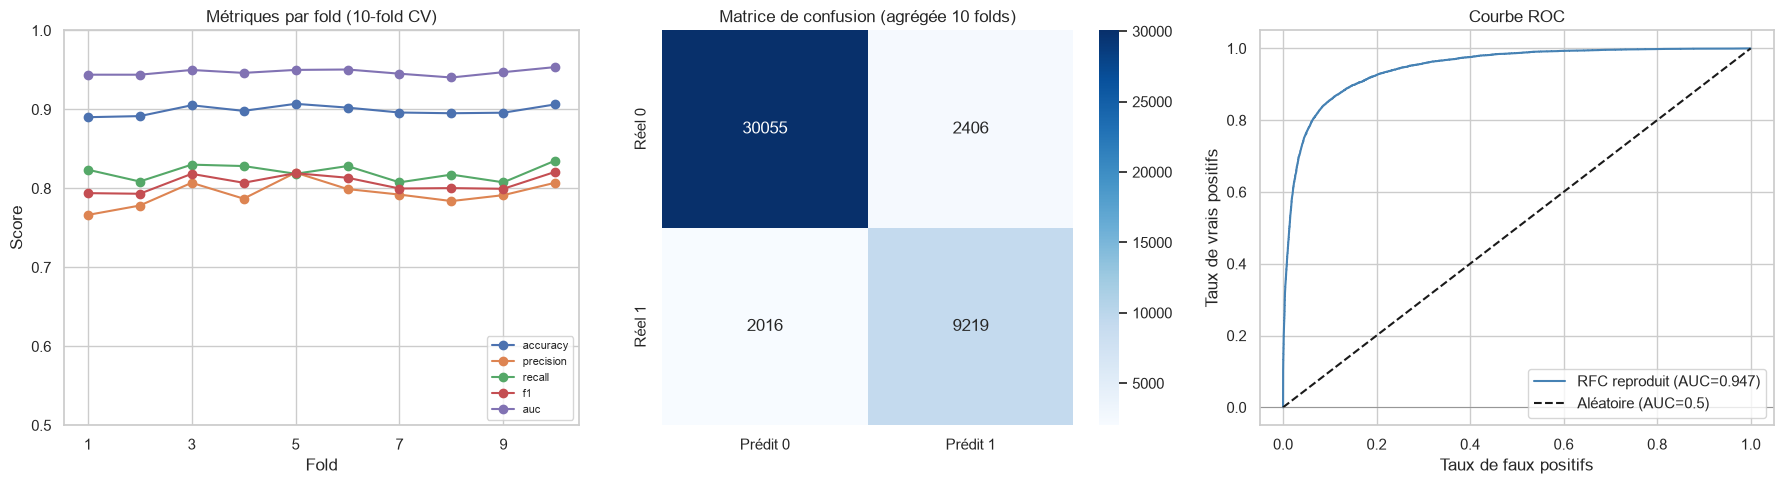

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Métriques par fold ---
ax = axes[0]
folds_plot = folds_df.drop(['mean', 'std']).drop(columns=['mcc'])
folds_plot.plot(ax=ax, marker='o')
ax.set_title('Métriques par fold (10-fold CV)')
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.0)
ax.legend(loc='lower right', fontsize=8)

# --- Matrice de confusion globale ---
ax = axes[1]
cm = confusion_matrix(all_y_true, all_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
ax.set_title('Matrice de confusion (agrégée 10 folds)')

# --- Courbe ROC globale ---
ax = axes[2]
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
auc_global = roc_auc_score(all_y_true, all_y_prob)
ax.plot(fpr, tpr, label=f'RFC reproduit (AUC={auc_global:.3f})', color='steelblue')
ax.plot([0,1],[0,1], 'k--', label='Aléatoire (AUC=0.5)')
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_title('Courbe ROC')
ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.legend()

plt.tight_layout()
plt.show()

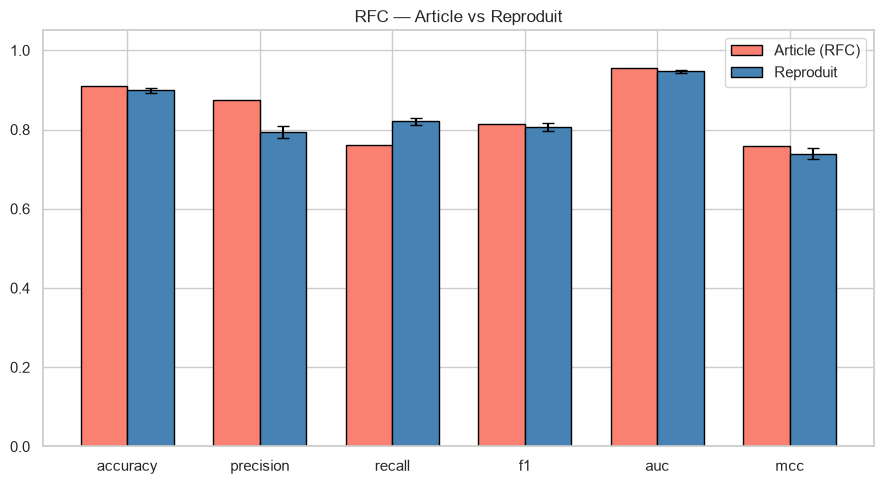

In [9]:
# Barplot comparaison article vs reproduit
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(metric_keys))
w = 0.35
ax.bar(x - w/2, [article_ref[k] for k in metric_keys], w, label='Article (RFC)', color='salmon',   edgecolor='black')
ax.bar(x + w/2, [means[k]       for k in metric_keys], w, label='Reproduit',     color='steelblue', edgecolor='black')
ax.errorbar(x + w/2, [means[k] for k in metric_keys],
            yerr=[stds[k] for k in metric_keys], fmt='none', color='black', capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(metric_keys)
ax.set_ylim(0, 1.05)
ax.set_title('RFC — Article vs Reproduit')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Importance des features (modèle entraîné sur tout le dataset)

In [10]:
# Entraîner sur tout X pour récupérer l'importance globale
rf_full = RandomForestClassifier(
    n_estimators=250, max_depth=100, min_samples_split=10,
    min_samples_leaf=1, criterion='entropy', class_weight='balanced',
    n_jobs=-1, random_state=RANDOM_STATE
)
rf_full.fit(X, y)
importances = pd.Series(rf_full.feature_importances_, index=feat_names)

# Agrégation par groupe de features
groups = {
    'squid (one-hot)' : importances[importances.index.str.startswith('squid_')].sum(),
    **{f'w2v_{l}': importances[importances.index.str.startswith(f'w2v_{l}')].sum() for l in LINES}
}
print('Importance agrégée par groupe :')
for g, v in sorted(groups.items(), key=lambda x: -x[1]):
    print(f'  {g:20s} : {v:.4f}')

Importance agrégée par groupe :
  w2v_line_0           : 0.4611
  w2v_line_m1          : 0.1216
  w2v_line_1           : 0.1130
  w2v_line_2           : 0.1130
  w2v_line_m2          : 0.1111
  squid (one-hot)      : 0.0802


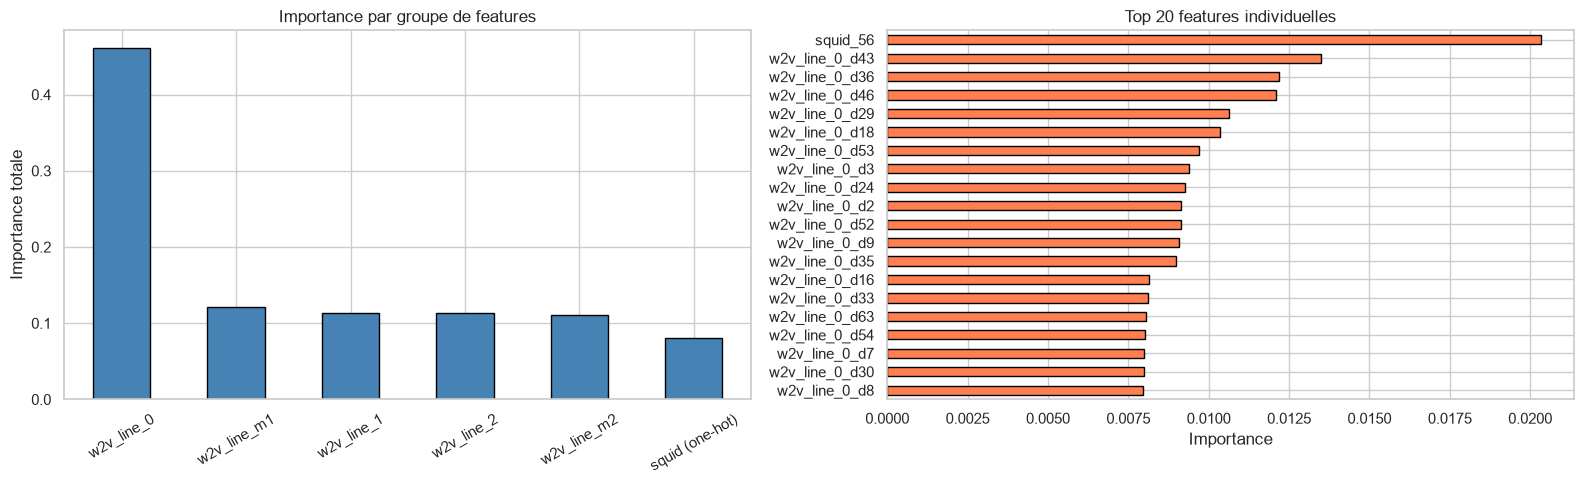

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Groupes
ax = axes[0]
g_series = pd.Series(groups).sort_values(ascending=False)
g_series.plot(kind='bar', ax=ax, edgecolor='black', color='steelblue')
ax.set_title('Importance par groupe de features')
ax.set_ylabel('Importance totale')
ax.tick_params(axis='x', rotation=30)

# Top 20 features individuelles
ax = axes[1]
top20 = importances.nlargest(20).sort_values()
top20.plot(kind='barh', ax=ax, edgecolor='black', color='coral')
ax.set_title('Top 20 features individuelles')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 8. Sauvegarde du modèle et des résultats

In [12]:
# Sauvegarde modèle
joblib.dump(rf_full, MODELS / 'rf_model.pkl')
print(f'Modèle sauvegardé : {MODELS / "rf_model.pkl"}')

# Résultats JSON
results_rf = {
    'model'       : 'RandomForestClassifier',
    'hyperparams' : {
        'n_estimators': 250, 'max_depth': 100, 'min_samples_split': 10,
        'min_samples_leaf': 1, 'criterion': 'entropy', 'class_weight': 'balanced'
    },
    'cv'          : '10-fold StratifiedKFold',
    'n_samples'   : int(X.shape[0]),
    'n_features'  : int(X.shape[1]),
    'fold_metrics': fold_results,
    'mean_metrics': {k: round(float(v), 4) for k, v in means.items()},
    'std_metrics' : {k: round(float(v), 4) for k, v in stds.items()},
    'article_ref' : article_ref,
    'delta_vs_article': {k: round(float(means[k] - article_ref[k]), 4) for k in metric_keys},
}

with open(RESULTS / 'results_rf.json', 'w', encoding='utf-8') as f:
    json.dump(results_rf, f, indent=2, ensure_ascii=False)

print(f'Résultats sauvegardés : {RESULTS / "results_rf.json"}')
print()
print('=== Résumé final ===')
for k in metric_keys:
    delta = means[k] - article_ref[k]
    sign  = '+' if delta >= 0 else ''
    print(f'  {k:12s} : {means[k]:.4f} ± {stds[k]:.4f}   '
          f'(article {article_ref[k]:.4f}, Δ={sign}{delta:.4f})')

Modèle sauvegardé : C:\Projects\SonarQube_FP\models\rf_model.pkl
Résultats sauvegardés : C:\Projects\SonarQube_FP\results\results_rf.json

=== Résumé final ===
  accuracy     : 0.8988 ± 0.0058   (article 0.9100, Δ=-0.0112)
  precision    : 0.7933 ± 0.0149   (article 0.8739, Δ=-0.0806)
  recall       : 0.8206 ± 0.0096   (article 0.7598, Δ=+0.0608)
  f1           : 0.8066 ± 0.0101   (article 0.8127, Δ=-0.0061)
  auc          : 0.9471 ± 0.0037   (article 0.9551, Δ=-0.0080)
  mcc          : 0.7384 ± 0.0140   (article 0.7572, Δ=-0.0188)
